In [1]:
import torch
import torchvision
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch import optim

In [8]:
print(torch.__version__)

2.10.0+cu128


In [9]:
print(torchvision.__version__)

0.25.0+cu128


In [10]:
train_data = datasets.FashionMNIST(
        root="cnndata",
        train=True,
        download=True,
        transform=ToTensor(),
        target_transform=None
    )
test_data = datasets.FashionMNIST(
        root="cnndata",
        train=False,
        download=True,
        transform=ToTensor(),
        target_transform=None
    )

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 194kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.33MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.3MB/s]


In [11]:
len(train_data), len(test_data)

(60000, 10000)

In [12]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [13]:
train_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [14]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [15]:
image.shape, label

(torch.Size([1, 28, 28]), 9)

Text(0.5, 1.0, '9')

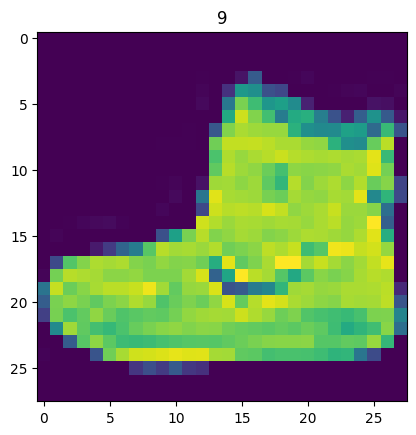

In [16]:
plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

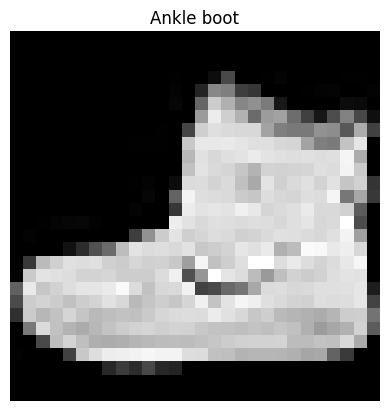

In [17]:
class_names = train_data.classes
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

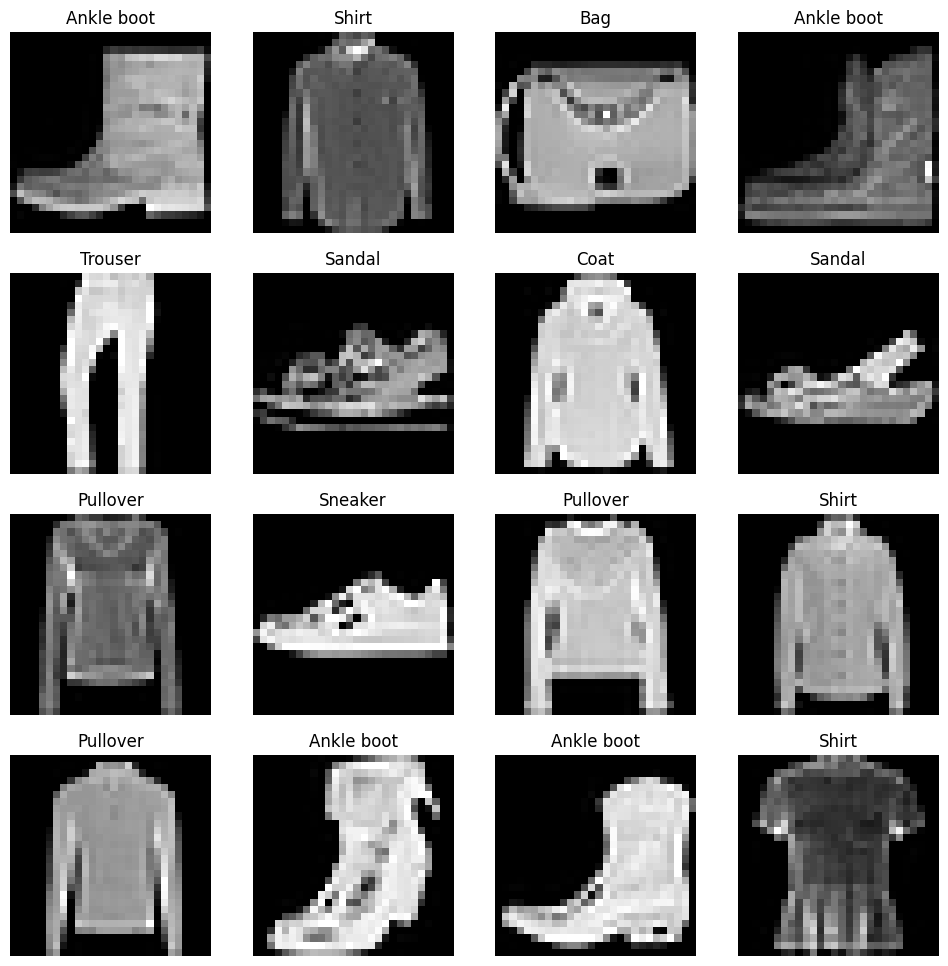

In [18]:
torch.manual_seed(42)
fig = plt.figure(figsize=(12,12))
rows, cols = 4,4
for i in range(1, rows*cols+1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

In [19]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False)

In [20]:
len(train_dataloader)

1875

In [21]:
train_features, train_labels = next(iter(train_dataloader))
test_features, test_labels = next(iter(test_dataloader))

torch.Size([1, 28, 28])
tensor(1)


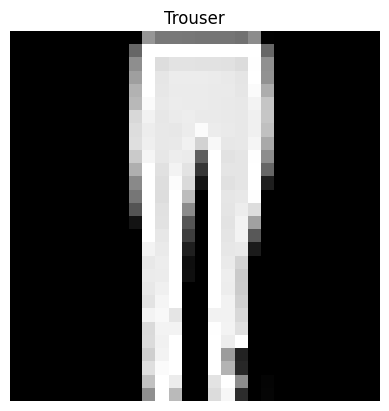

In [22]:
# torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features), size=[1]).item()
img, label = train_features[random_idx], train_labels[random_idx]
plt.imshow(img.squeeze(), cmap = "gray")
plt.title(class_names[label])
plt.axis(False)
print(img.shape)
print(label)

In [23]:
flatten_model = nn.Flatten()
x = train_features[0]

op=flatten_model(x)
x.shape # -> [channel, height, width]

torch.Size([1, 28, 28])

In [24]:
op.shape # -> [channel, height*width]

torch.Size([1, 784])

In [25]:
op.squeeze()

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0039, 0.0039, 0.0000, 0.0000, 0.0078, 0.0078,
        0.0000, 0.0000, 0.0039, 0.0078, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.2863, 0.0000, 0.0000, 0.0078, 

In [26]:
class damodel(nn.Module):
    def __init__(self, input, hidden_units, output):
        super().__init__()
        self.model = nn.Sequential(
                nn.Flatten(),
                nn.Linear(input, hidden_units),
                nn.ReLU(),
                nn.Linear(hidden_units, output),
                
            )
    def forward(self, x):
        return self.model(x)

In [27]:
torch.manual_seed(42)
model_0 = damodel(784, 256, len(class_names)) # o/p is 10 
device = "cuda" if torch.cuda.is_available() else "cpu"

model_0.to(device)


damodel(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [28]:
LR = 0.1
optimizer = optim.SGD(params=model_0.parameters(), lr = LR)
criterion = nn.CrossEntropyLoss()

In [29]:
import os
print(os.uname())

posix.uname_result(sysname='Linux', nodename='a7c54fd5718c', release='6.6.113+', version='#1 SMP Mon Feb  2 12:27:57 UTC 2026', machine='x86_64')


In [24]:
EPOCHS = 100
for epoch in range(EPOCHS):
    total_epoch_loss = 0
    for features, label in train_dataloader:
        features, label = features.to(device), label.to(device)

        output = model_0(features)

        loss = criterion(output, label)

        optimizer.zero_grad()

        loss.backward()
       
        optimizer.step()
        total_epoch_loss+=loss.item()

    avg_epoch_loss = total_epoch_loss / len(train_dataloader)
    print(f"Epoch : {epoch+1}  : Loss {avg_epoch_loss}")

Epoch : 1  : Loss 0.5564481460769971
Epoch : 2  : Loss 0.4005271001617114
Epoch : 3  : Loss 0.3594996248026689
Epoch : 4  : Loss 0.33516321555574735
Epoch : 5  : Loss 0.317021473445495
Epoch : 6  : Loss 0.3043839989364147
Epoch : 7  : Loss 0.29084511483510334
Epoch : 8  : Loss 0.27998211835026743
Epoch : 9  : Loss 0.27048254600564636
Epoch : 10  : Loss 0.2621321247637272
Epoch : 11  : Loss 0.25316641504565873
Epoch : 12  : Loss 0.24550868148008984
Epoch : 13  : Loss 0.23680994254946708
Epoch : 14  : Loss 0.23117613833347955
Epoch : 15  : Loss 0.22621533581614495
Epoch : 16  : Loss 0.2212706269979477
Epoch : 17  : Loss 0.21447160427719356
Epoch : 18  : Loss 0.20994825220108032
Epoch : 19  : Loss 0.20435972062697014
Epoch : 20  : Loss 0.2002104601005713
Epoch : 21  : Loss 0.19519482896228632
Epoch : 22  : Loss 0.1900452374656995
Epoch : 23  : Loss 0.18664037498285374
Epoch : 24  : Loss 0.18189689925312996
Epoch : 25  : Loss 0.17636230085343121
Epoch : 26  : Loss 0.1742686118796468
Epoch 

In [25]:
model_0.eval()
total, correct= 0, 0
with torch.inference_mode():
    for features, labels in test_dataloader:
        features, labels = features.to(device), labels.to(device)

        output = model_0(features)
        # loss+= criterion(output, labels).item()   
        total += labels.shape[0]
        correct += (output.argmax(dim = 1) == labels).sum().item()

    acc = correct/total
    print(f"acc:{acc}")
        

acc:0.8895


In [26]:
torch.save(model_0.state_dict(), "model_0.pth")

Model 2: CNNNNNNNNNNN less gooo


In [30]:
class cnnmodel(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.conv_block1 = nn.Sequential(
                nn.Conv2d(in_channels = input_shape, 
                          out_channels=hidden_units,
                          kernel_size = 3,
                          stride=1,
                          padding=1),
                nn.ReLU(),
                nn.Conv2d(in_channels=hidden_units, 
                          out_channels=hidden_units,
                          kernel_size=3,
                          stride=1,
                          padding=1
                          ),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2) # if stride is not mentioned stride = kernel_size
            )
        
        self.conv_block2 = nn.Sequential(
                nn.Conv2d(in_channels=hidden_units,
                          out_channels=hidden_units,
                          kernel_size=3,
                          stride=1,
                          padding=1),
                nn.ReLU(),
                nn.Conv2d(in_channels=hidden_units,
                          out_channels = hidden_units,
                          kernel_size=3,
                          stride=1,
                          padding=1,
                          ),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = 2)
            )
        self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(in_features=hidden_units * 7* 7,
                          out_features = output_shape)
            )
    def forward(self, x):
        x = self.conv_block1(x)
        
        x = self.conv_block2(x)
        
        x = self.classifier(x)
        return x

In [31]:
image.shape

torch.Size([1, 28, 28])

In [32]:
torch.manual_seed(42)
model_1 = cnnmodel(1, 10, len(class_names))
model_1.to(device)

cnnmodel(
  (conv_block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [31]:
def train_func(EPOCHS: int, model: nn.Module, train_dataloader: DataLoader, criterion: nn.Module, optimizer: optim.Optimizer ):
    for epoch in range(EPOCHS):
        total_epoch_loss = 0
        for features, labels in train_dataloader:
            features, labels = features.to(device), labels.to(device)
            output = model(features)
            loss = criterion(output, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_epoch_loss+=loss.item()
        avg_loss = total_epoch_loss / len(train_dataloader)
        print(f"Epoch {epoch+1} | Loss {avg_loss}")

def test_func(model: nn.Module, test_loader: DataLoader, criterion: nn.Module):
    model.eval()
    total, correct =0,0
    with torch.inference_mode():
        for features, labels in test_loader:
            features, labels = features.to(device), labels.to(device)
            op = model(features)
            # loss+= criterion(op, labels).item()
            correct += (op.argmax(dim=1) == labels).sum().item() 
            total+=labels.shape[0]
        print(f"Acc: {correct / total}")


In [ ]:
criterion = nn.CrossEntropyLoss()
torch.cuda.manual_seed(42)
EPOCHS = 100
optimi = optim.SGD(model_1.parameters(), lr = 0.01, momentum = .9)
train_func(EPOCHS, model_1, train_dataloader, criterion, optimi)


In [33]:
test_func(model_1, test_dataloader, criterion)

Acc: 0.9038


In [34]:
torch.save(model_1.state_dict(), "model_1.pth")

In [39]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [41]:
model_1 = cnnmodel(1, 10, len(class_names)).to(device)
model_1.load_state_dict(torch.load("/content/drive/MyDrive/PyTorchShen/model_1.pth"))

<All keys matched successfully>

In [42]:
def make_pred(model, data):
    pred_probs=[]
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)

            pred_logit = model(sample)

            pred_probs.append(torch.softmax(pred_logit.squeeze(), dim=0).cpu())

    return torch.stack(pred_probs)

In [43]:
import random
# random.seed(42)
test_samples = []
test_labels = []

for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)



In [44]:
pred_probs = make_pred(model_1, test_samples)
pred_labels = pred_probs.argmax(dim=1)


In [45]:
pred_probs[:2], pred_labels

(tensor([[1.6455e-05, 1.7891e-10, 5.7825e-03, 4.8087e-09, 9.5905e-01, 1.6425e-12,
          3.5156e-02, 4.1199e-14, 1.5753e-09, 1.1448e-09],
         [8.0882e-10, 7.0815e-17, 5.6225e-14, 1.0087e-15, 3.8414e-16, 5.9433e-06,
          1.8577e-13, 6.0342e-05, 8.4945e-10, 9.9993e-01]]),
 tensor([4, 9, 0, 9, 1, 2, 2, 6, 5]))

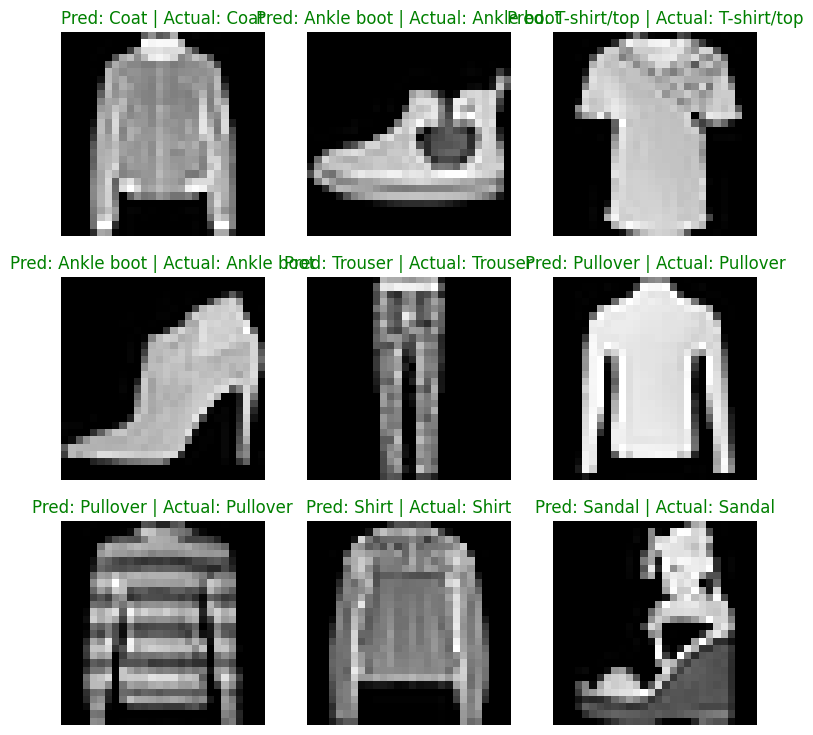

In [46]:
fig = plt.figure(figsize=(9,9))
rows, cols = 3,3
for i, sample in enumerate(test_samples):
    plt.subplot(rows, cols, i+1)
    
    plt.imshow(sample.squeeze(), cmap="gray")

    pred_label = class_names[pred_labels[i]]

    actual_label = class_names[test_labels[i]]

    title_text = f"Pred: {pred_label} | Actual: {actual_label}"

    if pred_label ==actual_label:
        plt.title(title_text, c='g')
    else:
        plt.title(title_text, c='r')
    plt.axis(False)


In [48]:
# !zip models.zip model_0.pth model_1.pth
# from google.colab import files
# files.download("models.zip")

In [63]:
y_pred = []
model_1.eval()
with torch.inference_mode():
    for x,y in test_dataloader:
        x, y = x.to(device), y.to(device)
        logits = model_1(x)
        pred = torch.softmax(logits.squeeze(), dim = 0).argmax(dim = 1)
        y_pred.append(pred.cpu())
y_pred_tensor = torch.cat(y_pred)

In [49]:
import mlxtend
print(mlxtend.__version__)

0.23.4


In [50]:
!pip install torchmetrics
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix



In [64]:
y_pred_tensor.shape

torch.Size([10000])

In [66]:
confmat = ConfusionMatrix(num_classes=len(class_names), task="multiclass")
confmat_tensor = confmat(preds = y_pred_tensor, target= test_data.targets)


In [70]:
confmat_tensor

tensor([[667,   5,  30,  67,   9,   0, 222,   0,   0,   0],
        [ 24, 859,   3,  82,  11,   3,  15,   0,   3,   0],
        [ 21,   4, 697,  28, 125,   0, 122,   0,   3,   0],
        [ 35,  15,   9, 853,  34,   0,  53,   0,   1,   0],
        [  5,   5,  82,  61, 719,   0, 123,   0,   5,   0],
        [ 66,   2,   2,  22,   4, 674,  21,  96,  91,  22],
        [ 97,   6,  61,  69,  79,   0, 687,   0,   1,   0],
        [  2,   0,   0,   0,   0,  27,   0, 931,   7,  33],
        [ 49,   9,  15,  38,  28,  10, 113,   8, 729,   1],
        [  4,   1,   0,   6,   1,  23,   9, 162,  15, 779]])

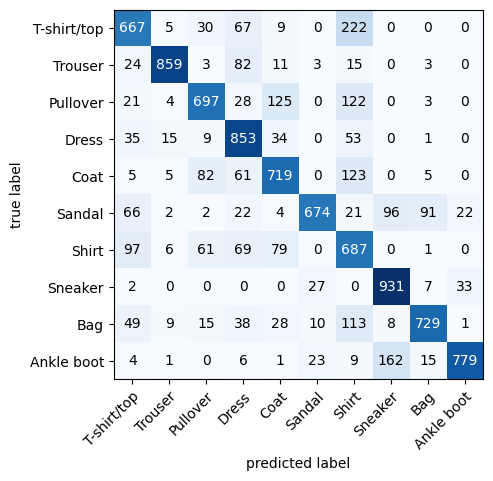

In [73]:
fig, ax = plot_confusion_matrix(
        conf_mat = confmat_tensor.numpy(),
        class_names = class_names
    )